In [1]:
import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits
from torch.nn import functional as F
import torchvision
from torchvision.transforms import ToTensor, Lambda
from torch import nn, optim

c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
from torch.utils.data import DataLoader, random_split

# %% MNIST dataset
num_classes = 10
batch_size = 32

# target_transform = Lambda(
#     lambda y: torch.zeros(num_classes).scatter_(0, torch.tensor(y), 1)
# )

full_train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=ToTensor(),
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=ToTensor(),
)


In [3]:
train_size = 50000
val_size   = 10000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [5]:
class LeNet_5(nn.Module):
    def __init__(self,
                 in_channels=1,
                 out_channels1=6,
                 kernel_size1=(5,5),
                 pool_size1=(2,2),
                 
                 out_channels2=16,
                 kernel_size2=(5,5),
                 pool_size2=(2,2),
                 
                 n_fc1=120,
                 n_fc2=84,
                 n_fc3= 10):
        super(LeNet_5, self).__init__()
        
        self.conv1= nn.Conv2d(in_channels=in_channels,
                              out_channels=out_channels1,
                              kernel_size=kernel_size1,
                              padding= (kernel_size1[0]//2, kernel_size1[1]//2),
                              groups=1)
        
        self.pool1= nn.AvgPool2d(kernel_size=pool_size1,
                                 stride=pool_size1)
        
        self.conv2= nn.Conv2d(in_channels=out_channels1,
                              out_channels=out_channels2,
                              kernel_size=kernel_size2,
                              groups=1)
        
        self.pool2= nn.AvgPool2d(kernel_size=pool_size2,
                                 stride=pool_size2)
      
        self.fc1= nn.LazyLinear(out_features=n_fc1)
        self.fc2= nn.LazyLinear(out_features=n_fc2)
        self.fc3= nn.LazyLinear(out_features=n_fc3)
        
        self.fun= nn.ReLU()
    
    def forward(self,X):
       # X: bs x 1 x H x W
       out= self.conv1(X)
       out= self.fun(out)
       out= self.pool1(out)
       
       out= self.conv2(out)
       out= self.fun(out)
       out= self.pool2(out)
       # flattening 
       flat= out.flatten(start_dim=1)
       out= self.fc1(flat)
       out= self.fun(out)       
       out= self.fc2(out)
       out= self.fun(out)
       out= self.fc3(out)
       return out

In [6]:
model= LeNet_5(in_channels=1,
                out_channels1=6,
                kernel_size1=(5,5),
                pool_size1=(2,2),
                
                out_channels2=16,
                kernel_size2=(5,5),
                pool_size2=(2,2),
                
                n_fc1=120,
                n_fc2=84,
                n_fc3= 10)
n_out=10

criterion= nn.CrossEntropyLoss()
optimizer= optim.SGD(params=model.parameters(),
                      lr=0.01,momentum=0.9)

In [7]:
mse=[]
epoch=2
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          model.train()
          # farward pass
          ypred= model(xbatch)
          optimizer.zero_grad()
          loss= criterion(ypred,ybatch.long())
          loss.backward()
          optimizer.step()

          er.append(loss.detach()) 
          if i%5==0:
               model.eval()
               loss= torch.mean(torch.tensor(er))
               mse.append(loss)
               # validation
               with torch.no_grad():
                    y_pred=[]
                    y_true=[]
                    for j,(xbatch,ybatch) in enumerate(val_loader):
                         # farward pass
                         ypred= model(xbatch)
                         ypred= torch.argmax(ypred,dim=1)
                         y_pred.extend(ypred.numpy())
                         y_true.extend(ybatch.numpy())
                         
                    y_pred= np.array(y_pred)
                    y_true= np.array(y_true)
                    accuracy= np.sum(y_true==y_pred)/y_pred.shape[0]*100
                    print(f'MSE({iter}:{i}): {loss:.6f} **** Acc:{accuracy:.3f}%')
               model.train()
mse=torch.tensor(mse)

plt.subplot(2,1,1)
plt.plot(mse)
plt.show()

MSE(0:0): 2.313682 **** Acc:9.780%
MSE(0:5): 2.315536 **** Acc:9.780%
MSE(0:10): 2.312718 **** Acc:9.780%
MSE(0:15): 2.307247 **** Acc:9.780%
MSE(0:20): 2.306425 **** Acc:9.780%
MSE(0:25): 2.304918 **** Acc:19.040%
MSE(0:30): 2.305443 **** Acc:11.270%
MSE(0:35): 2.304047 **** Acc:11.270%
MSE(0:40): 2.304895 **** Acc:11.270%
MSE(0:45): 2.305351 **** Acc:11.270%
MSE(0:50): 2.305146 **** Acc:11.270%
MSE(0:55): 2.305122 **** Acc:11.270%
MSE(0:60): 2.305076 **** Acc:11.270%
MSE(0:65): 2.304479 **** Acc:11.270%
MSE(0:70): 2.303928 **** Acc:11.270%
MSE(0:75): 2.303951 **** Acc:11.270%
MSE(0:80): 2.303822 **** Acc:11.270%
MSE(0:85): 2.303454 **** Acc:11.270%
MSE(0:90): 2.303046 **** Acc:11.270%
MSE(0:95): 2.302956 **** Acc:11.880%
MSE(0:100): 2.302593 **** Acc:18.060%
MSE(0:105): 2.301969 **** Acc:18.690%
MSE(0:110): 2.301663 **** Acc:19.760%
MSE(0:115): 2.301240 **** Acc:20.140%
MSE(0:120): 2.300387 **** Acc:19.510%
MSE(0:125): 2.299959 **** Acc:16.990%
MSE(0:130): 2.299325 **** Acc:14.460%
M

KeyboardInterrupt: 

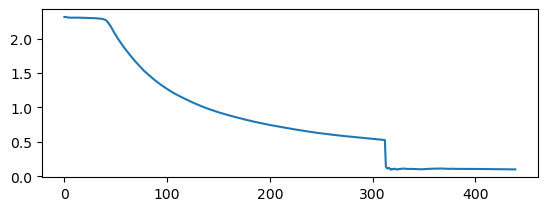

In [8]:
plt.subplot(2,1,1)
plt.plot(mse)
plt.show()

Total accuracy:96.180%
accuracy0:98.878%
accuracy1:98.590%
accuracy2:97.868%
accuracy3:87.030%
accuracy4:94.603%
accuracy5:99.552%
accuracy6:98.852%
accuracy7:96.401%
accuracy8:97.023%
accuracy9:93.261%


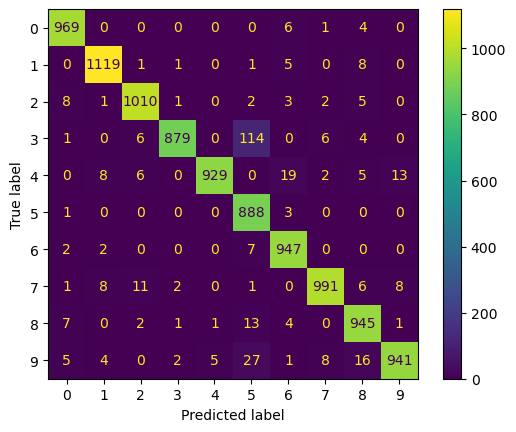

In [9]:
# validation
y_pred=[]
y_true=[]
model.eval()
with torch.no_grad():
    for i,(xbatch,ybatch) in enumerate(test_loader):
        # farward pass
        ypred= model(xbatch)
        ypred= torch.argmax(ypred,dim=1)
        y_pred.extend(ypred.numpy())
        y_true.extend(ybatch.numpy())
        
    y_pred= np.array(y_pred)
    y_true= np.array(y_true)

    from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
    #%% test trained Neural Network
    C= confusion_matrix(y_true,y_pred)
    # print(C)
    accuracy= np.sum(np.diag(C))/ np.sum(C) *100
    print(f'Total accuracy:{accuracy:.3f}%')

for i in range(n_out):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()